In [1]:
%load_ext autoreload
%autoreload 2
import torch
from utils import goto_project_root
from utils.path_settings import MODEL_SAVE_PATH, DATA_PATH, LOG_PATH, CONFIG_PATH, OBJECT_PATH
from torch.utils.tensorboard import SummaryWriter
import SimulateDatasets.GenTrainingData as g
from utils import create_splits, get_dataloaders, force_remove_dir
from Network_models import Trainer as t
from importlib import reload
import os
reload(t)
reload(g)
import time
import numpy as np
from pytorch3d.transforms import so3_relative_angle
from pytorch3d.transforms import quaternion_to_matrix
import json
import Train_task.train_from_config_names as train
from SimulateDatasets import RendererGenerator as r
reload(train)
import torchvision.models as models
from torchvision.models import ConvNeXt_Tiny_Weights

In [2]:
obj_path_dict = {
    "cow": OBJECT_PATH + "\\cow_mesh\\cow.obj",
    "A1": OBJECT_PATH + "\\stim_simple\\A1_5x6x5_centered.obj",
    "A2": OBJECT_PATH + "\\stim_simple\\A2_5x6x5_centered.obj",
    "B1": OBJECT_PATH + "\\stim_simple\\B1_6x6x6_centered.obj",
    "B2": OBJECT_PATH + "\\stim_simple\\B2_6x6x6_centered.obj",
    "C1": OBJECT_PATH + "\\stim_simple\\C1_5x6x5_centered.obj",
    "C2": OBJECT_PATH + "\\stim_simple\\C2_5x6x5_centered.obj",
    "D1": OBJECT_PATH + "\\stim_simple\\D1_5x6x5_centered.obj",
    "D2": OBJECT_PATH + "\\stim_simple\\D2_5x6x5_centered.obj",
    "E1": OBJECT_PATH + "\\stim_simple\\E1_5x5x6_centered.obj",
    "E2": OBJECT_PATH + "\\stim_simple\\E2_5x5x6_centered.obj",
}
obj_index_dict = {
    "cow": None, 
    "A1": "5x6x5_centered",
    # "A2": "5x6x5_centered",
    # "B1": "6x6x6_centered",
    # "B2": "6x6x6_centered",
    # "C1": "5x6x5_centered",
    # "C2": "5x6x5_centered",
    # "D1": "5x6x5_centered",
    # "D2": "5x6x5_centered",
    # "E1": "5x5x6_centered",
    # "E2": "5x5x6_centered",
}
cam_position = {
    "cow": 3,
    "A1": 8,
    "A2": 8,
    "B1": 8,
    "B2": 8,
    "C1": 8,
    "C2": 8,
    "D1": 8,
    "D2": 8,
    "E1": 8,
    "E2": 8,
}

In [14]:
obj_path_dict.get("cow", None)

'C:\\Users\\timmy\\Documents\\Projects_dir\\Mental_Rotations\\mental-rotations\\data\\cow_mesh\\cow.obj'

In [22]:
obj_name = "cow"
obj_index = obj_index_dict.get(obj_name, None)
obj_path = obj_path_dict.get(obj_name, None)
cam_pos = cam_position.get(obj_name, None)
obj_name = obj_name + "_" + obj_index + ".obj" if obj_index is not None else obj_name + ".obj"
FC_size = 16 # This is the input size for the RNN part of the RNN structure (we will be loading FC_RNN).
rnn_hidden_size = 8
task_RNN_pretrained = "0.1q"
rnn_cell_type = "GRU"
rnn_special_name = "constant_rework_output_noise"
distance_loss = "geodesic_gradual"
seq_len = 100
prep_phase = 50
task_name = "1.1"
re_train = 1
resolution = 128

network_name = "ConvNeXt_Tiny_" + f"FC_{FC_size}_GRU_{rnn_hidden_size}_silence_suppressed" + obj_name.strip(".obj")
silence_suppressed = False

config = {"model_specs": {
    "model_name": "Imported_CNN_RNN",  # to be added (CustomRNN or FC_RNN)
    "model_path": "Network_models.CNN_models",
    "model_params": {
        "convnet": "ConvNeXt_Tiny",
        "weight_string": "IMAGENET1K_V1", 
        "freeze_conv": True,
        "rnn_input_size": FC_size,
        "rnn": {
            "freeze_rnn": False, 
            "model_name": "FC_RNN",
            "model_path": "Network_models.RNN_models",
            "remove_FC": True, 
            "saved_state_dict_path": None,
            "model_params": {
                "input_size": 8,
                "hidden_size": rnn_hidden_size, # to be changed
                "num_layers": 1, # to be changed
                "output_size": 3,
                "FC_dim": FC_size,
                "cell_type": rnn_cell_type,  # to be added
            }, 
            "stepwise": False, 
            "saved_model_path": MODEL_SAVE_PATH + 
                                f"\\FC_{FC_size}_{rnn_cell_type}_{1}layer_{rnn_hidden_size}hidden_"
                                f"{'silence_suppressed_' if silence_suppressed else ''}"
                                f"{task_RNN_pretrained}"
                                f"_model_{'gradual' if distance_loss[-7:] == 'gradual' else ''}"
                                f"{'_' + rnn_special_name if rnn_special_name is not None else ''}\\best_model.pth",
        }, 
    }
}, "model_id": network_name, "device": "cuda", "scheduler": True, # Uses the ReduceLROnPlateau scheduler
    "optimizer_specs": {
    "optimizer_name": "Adam",
    "optimizer_params": {
        "lr": 0.001
    }
}, "distance_loss": distance_loss, "gradual_loss_weighting": "constant+linear", "regularisation_loss": "L2",
    "distance_weight": 1, "output_regs_weight": 0, "silence_activity": False,
    # silence_activity is the knob for suppressing activity in the silence phase
    "training_config": {
        "task_id": "1.1",
        "batch_size": 512,
        "mini_batch_size": 128,
        "seq_len": seq_len,
        "prep_phase": prep_phase,
        "resolution": resolution,
        "cam_position": cam_pos,
        "object_path": obj_path,
        "epochs_to_calculate": 5,
        "replacement_tolerance": 0.5,
        "use_AR": True, 
    }, 'save_path': MODEL_SAVE_PATH + f"\\{network_name}_{task_name}_model", 'log_path': LOG_PATH,
    'check_path': MODEL_SAVE_PATH + f"\\{network_name}_model_checkpoints", 
    "silence_activity_loss": "L2" if silence_suppressed else None,
    "silence_activity_weight": 0
}
config['training_config']['data_save_path'] = (DATA_PATH + 
                                               f"\\Data_{task_name}_res{config['training_config']['resolution']}_{obj_name[:-4]}"
                                               f".pth")

if config['distance_loss'][-7:] == "gradual":
    config['save_path'] = MODEL_SAVE_PATH + (f"\\{network_name}_{task_name}_res{config['training_config']['resolution']}"
                                             f"_model_gradual")
    config['check_path'] = (MODEL_SAVE_PATH + 
                            f"\\{network_name}_res{config['training_config']['resolution']}_model_checkpoints_gradual")
    config['log_path'] = LOG_PATH + (f"\\{network_name}_{task_name}_res{config['training_config']['resolution']}"
                                     f"_model_gradual")
    config['model_specs']['model_params']['stepwise'] = True
else:
    config['model_specs']['model_params']['stepwise'] = False

for path in [config['save_path'], config['log_path'], config['check_path']]:
    if not os.path.exists(path):
        os.makedirs(path)
    elif not re_train:
        print(f"Path already exists for {network_name} in task {task_name}. Assume the model is already trained.")
    else: # re_train
        force_remove_dir(path)
        os.makedirs(path)
print(config['save_path'])
json.dump(config, open(CONFIG_PATH + f"\\{network_name}_{task_name}_res{config['training_config']['resolution']}_configs"
                                     f".json", 
                       "w"))

D:\Projects\mental-rotations\models\ConvNeXt_Tiny_FC_16_GRU_8_silence_suppressedcow_1.1_res128_model_gradual


# Using unlimited data to train

In [23]:
experimental_trainer = t.Trainer(config)
experimental_trainer.model.resolution = config['training_config']['resolution'] 

print(f"Training {network_name} on task {task_name}, saving to {config['save_path']}; copy the below for logs")
print(f"tensorboard --logdir={config['log_path']}")

epochs = 30
num_inits = 1
for i in range(num_inits):
    sub_log_path = config["log_path"] + f"\\split_{i + 1}"
    sub_check_path = config["check_path"] + f"\\split_{i + 1}"

    force_remove_dir(sub_log_path) # Probably redundant but helps to ensure no old logs are kept
    os.makedirs(sub_log_path, exist_ok = True)
    os.makedirs(sub_check_path, exist_ok = True)

    # keep a record on the best split: 
    best_split_val_loss = torch.tensor(float('inf'))
    print(f"Training split {i + 1}")

    generator = r.RendererGenerator(config['training_config'])

    experimental_trainer.train_unlimited(
        generator,
        epochs=epochs,
        save_path = config["save_path"] + f"\\model_{i+1}.pth",
        check_path= sub_check_path,
        log_path = sub_log_path, 
        early_stop = True,
    )
    if experimental_trainer.best_val_loss < best_split_val_loss:
        best_split_val_loss = experimental_trainer.best_val_loss
        best_split = i + 1

    experimental_trainer.save_model(config["save_path"] + f"\\model_{i+1}.pth", full=1)
experimental_trainer.load_best_model()
print(f"Training {network_name} on task {task_name} complete. Saving best model to {config['save_path']}.")
experimental_trainer.save_model(config["save_path"] + f"\\best_model.pth", full=1)


An exception occurred in telemetry logging.Disabling telemetry to prevent further exceptions.
Traceback (most recent call last):
  File "C:\Users\timmy\anaconda3\envs\mental-rotations\lib\site-packages\iopath\common\file_io.py", line 946, in __log_tmetry_keys
    handler.log_event()
  File "C:\Users\timmy\anaconda3\envs\mental-rotations\lib\site-packages\iopath\common\event_logger.py", line 97, in log_event
    del self._evt
AttributeError: _evt


Using a scheduler
Training ConvNeXt_Tiny_FC_16_GRU_8_silence_suppressedcow on task 1.1, saving to D:\Projects\mental-rotations\models\ConvNeXt_Tiny_FC_16_GRU_8_silence_suppressedcow_1.1_res128_model_gradual; copy the below for logs
tensorboard --logdir=D:\Projects\mental-rotations\logs\ConvNeXt_Tiny_FC_16_GRU_8_silence_suppressedcow_1.1_res128_model_gradual
Directory does not exist: D:\Projects\mental-rotations\logs\ConvNeXt_Tiny_FC_16_GRU_8_silence_suppressedcow_1.1_res128_model_gradual\split_1
Training split 1
Epoch 0, learning rate: 0.001
Replaced 65.38265991210938% of the data, new data size: 512, original size: 512
Training ConvNeXt_Tiny_FC_16_GRU_8_silence_suppressedcow on task 1.1 complete. Saving best model to D:\Projects\mental-rotations\models\ConvNeXt_Tiny_FC_16_GRU_8_silence_suppressedcow_1.1_res128_model_gradual.


Using a scheduler
Average geodesic distance: 2.419222354888916
Average geodesic distance: 0.05451889708638191


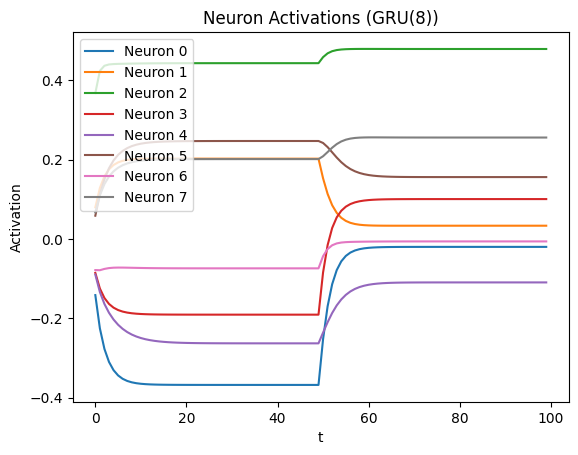

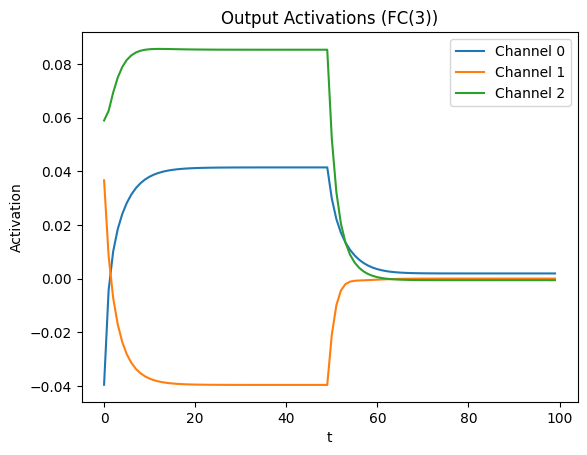

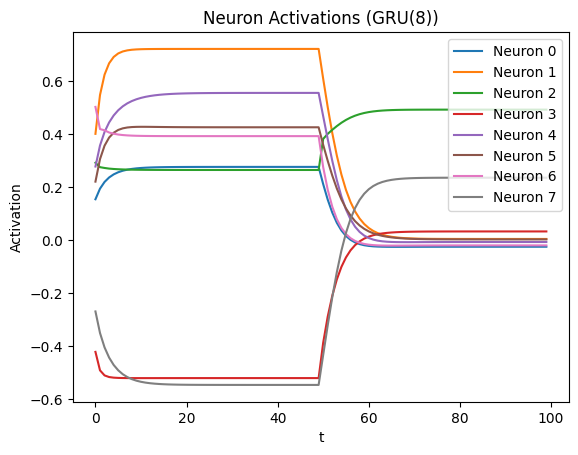

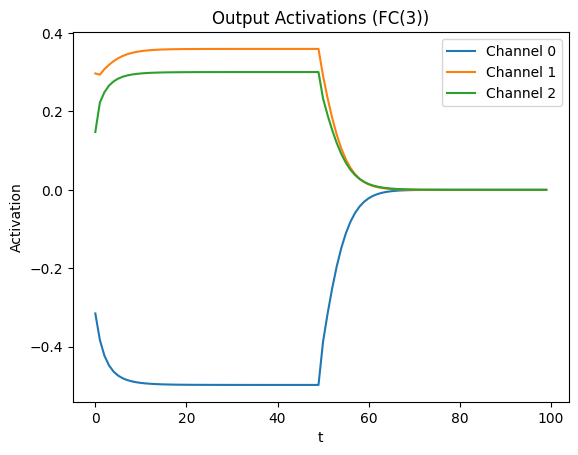

In [28]:
import matplotlib.pyplot as plt
from utils.path_settings import *

configs = [CONFIG_PATH + f"\\{network_name}_{task_name}_res{config['training_config']['resolution']}_configs"]
for config_path in configs: 
    config = json.load(open(config_path + ".json", "r"))
    rnn_trainer = t.Trainer(config)
    rnn_trainer.load_model(config["save_path"] + "\\best_model.pth", full=True)
    rnn_trainer.model.eval()
    # Let's print an average of geodesic distances between network output and target, for a batch of 1000 random quaternions 
    # where all parts are positive. 
    test_data = torch.load(config['training_config']['data_save_path'][:-4] + "_test.pth")
    test_dataloader = torch.utils.data.DataLoader(test_data, batch_size = 1, shuffle = False)
    features, target = next(iter(test_dataloader)) # Get a single batch
    features = features.to(config['device'])
    target = target.to(config['device'])
    rnn_trainer.model(features)
    pred = rnn_trainer.model.pred
    g_loss = rnn_trainer.distance_loss(pred, target)
    print(f"Average geodesic distance: {g_loss[1].mean()}")
    model = rnn_trainer.model


    def get_hidden_state(module, input, output):
        global hidden_states
        hidden_states.append(output[0].detach().clone())


    model.rnn.register_forward_hook(get_hidden_state)
    hidden_states = []
    out = model(features)
    activations = hidden_states[0][0:, :]  # Get the single tensor from the list
    activations = activations.view(-1, activations.shape[-1])  # Flatten to (batch_size * seq_len, hidden_unit_num)
    activations = activations.cpu().detach().numpy()

    time = np.arange(100)
    fig, ax = plt.subplots()
    for neuron in range(model.rnn.hidden_size):
        ax.plot(time, activations[:, neuron], label=f"Neuron {neuron}")
    ax.legend()
    ax.set_xlabel('t')
    ax.set_ylabel('Activation')
    ax.set_title('Neuron Activations (GRU(8))')
    save_name = config_path[(len(CONFIG_PATH)+1):-7]
    fig.savefig(FIG_PATH + "\\neuron_activations\\" + save_name + "hidden_activations.png")
    fig, ax = plt.subplots()
    time = np.arange(100)
    for output in range(3):
        ax.plot(time, out[0, :, output].cpu().detach().numpy(), label=f"Channel {output}")
    ax.legend()
    ax.set_xlabel('t')
    ax.set_ylabel('Activation')
    ax.set_title('Output Activations (FC(3))')
    fig.savefig(FIG_PATH + "\\neuron_activations\\" + save_name + "output_activations.png")
    
    # Now, visualise the activity of the RNN carried within the network, on itself facing the input. 
    rnn_trainer.load_model(config["model_specs"]["model_params"]["rnn"]["saved_model_path"], full=True)
    rnn_trainer.model.eval()

    hidden_states = []
    rnn_trainer.model.rnn.register_forward_hook(get_hidden_state)
    features = torch.cat((target, -target), -1).repeat(1, config['training_config']['prep_phase'], 1)
    features = torch.cat((features, torch.zeros_like(features)), -2)
    
    out = rnn_trainer.model(features)
    activations = hidden_states[0][0:, :]  # Get the single tensor from the list
    activations = activations.view(-1, activations.shape[-1])  # Flatten to (batch_size * seq_len, hidden_unit_num)
    activations = activations.cpu().detach().numpy()
    pred = rnn_trainer.model.pred
    g_loss = rnn_trainer.distance_loss(pred, target)
    print(f"Average geodesic distance: {g_loss[1].mean()}")
    fig, ax = plt.subplots()
    for neuron in range(model.rnn.hidden_size):
        ax.plot(time, activations[:, neuron], label=f"Neuron {neuron}")
    ax.legend()
    ax.set_xlabel('t')
    ax.set_ylabel('Activation')
    ax.set_title('Neuron Activations (GRU(8))')
    save_name = config_path[(len(CONFIG_PATH)+1):-7]
    fig, ax = plt.subplots()
    time = np.arange(100)
    for output in range(3):
        ax.plot(time, out[0, :, output].cpu().detach().numpy(), label=f"Channel {output}")
    ax.legend()
    ax.set_xlabel('t')
    ax.set_ylabel('Activation')
    ax.set_title('Output Activations (FC(3))')
    
    

In [61]:
obj_name = "cow"
obj_index = obj_index_dict.get(obj_name, None)
obj_path = obj_path_dict.get(obj_name, None)
cam_pos = cam_position.get(obj_name, None)
obj_name = obj_name + "_" + obj_index + ".obj" if obj_index is not None else obj_name + ".obj"
task_name = "1.1"
re_train = 1
resolution = 64
distance_loss = "geodesic"

network_name = "ConvNeXt_Tiny_" + f"Direct_Inference" + obj_name.strip(".obj")
silence_suppressed = False

config = {"model_specs": {
    "model_name": "Imported_CNN_Infer",  # to be added (CustomRNN or FC_RNN)
    "model_path": "Network_models.CNN_models",
    "model_params": {
        "convnet": "ConvNeXt_Tiny",
        "weight_string": "IMAGENET1K_V1", 
        "freeze_conv": True,
        "rnn_input_size": FC_size,
    }
}, "model_id": network_name, "device": "cuda", "scheduler": True, # Uses the ReduceLROnPlateau scheduler
    "optimizer_specs": {
    "optimizer_name": "Adam",
    "optimizer_params": {
        "lr": 0.01
    }
}, "distance_loss": distance_loss, "gradual_loss_weighting": "constant+linear", "regularisation_loss": "L2",
    "distance_weight": 1, "output_regs_weight": 0,
    # silence_activity is the knob for suppressing activity in the silence phase
    "training_config": {
        "task_id": "1.1",
        "batch_size": 512,
        "mini_batch_size": 512,
        "resolution": resolution,
        "cam_position": cam_pos,
        "object_path": obj_path,
        "epochs_to_calculate": 10,
        "replacement_tolerance": 0.2,
        "use_AR": True, 
    }, 'save_path': MODEL_SAVE_PATH + f"\\{network_name}_{task_name}_model", 'log_path': LOG_PATH,
    'check_path': MODEL_SAVE_PATH + f"\\{network_name}_model_checkpoints", 
}
config['training_config']['data_save_path'] = (DATA_PATH + 
                                               f"\\Data_{task_name}_res{config['training_config']['resolution']}_{obj_name[:-4]}"
                                               f".pth")

if config['distance_loss'][-7:] == "gradual":
    config['save_path'] = MODEL_SAVE_PATH + (f"\\{network_name}_{task_name}_res{config['training_config']['resolution']}"
                                             f"_model_gradual")
    config['check_path'] = (MODEL_SAVE_PATH + 
                            f"\\{network_name}_res{config['training_config']['resolution']}_model_checkpoints_gradual")
    config['log_path'] = LOG_PATH + (f"\\{network_name}_{task_name}_res{config['training_config']['resolution']}"
                                     f"_model_gradual")
    config['model_specs']['model_params']['stepwise'] = True
else:
    config['save_path'] = MODEL_SAVE_PATH + (f"\\{network_name}_{task_name}_res{config['training_config']['resolution']}"
                                             f"_model")
    config['check_path'] = (MODEL_SAVE_PATH + 
                            f"\\{network_name}_res{config['training_config']['resolution']}_model_checkpoints")
    config['log_path'] = LOG_PATH + (f"\\{network_name}_{task_name}_res{config['training_config']['resolution']}")
    config['model_specs']['model_params']['stepwise'] = False

for path in [config['save_path'], config['log_path'], config['check_path']]:
    if not os.path.exists(path):
        os.makedirs(path)
    elif not re_train:
        print(f"Path already exists for {network_name} in task {task_name}. Assume the model is already trained.")
    else: # re_train
        force_remove_dir(path)
        os.makedirs(path)
print(config['save_path'])

Successfully removed directory: D:\Projects\mental-rotations\models\ConvNeXt_Tiny_Direct_Inferencecow_1.1_res64_model
Successfully removed directory: D:\Projects\mental-rotations\logs\ConvNeXt_Tiny_Direct_Inferencecow_1.1_res64
Successfully removed directory: D:\Projects\mental-rotations\models\ConvNeXt_Tiny_Direct_Inferencecow_res64_model_checkpoints
D:\Projects\mental-rotations\models\ConvNeXt_Tiny_Direct_Inferencecow_1.1_res64_model


In [63]:
experimental_trainer = t.Trainer(config)
experimental_trainer.model.resolution = config['training_config']['resolution'] 

print(f"Training {network_name} on task {task_name}, saving to {config['save_path']}; copy the below for logs")
print(f"tensorboard --logdir={config['log_path']}")

epochs = 30
num_inits = 1
for i in range(num_inits):
    sub_log_path = config["log_path"] + f"\\split_{i + 1}"
    sub_check_path = config["check_path"] + f"\\split_{i + 1}"

    force_remove_dir(sub_log_path) # Probably redundant but helps to ensure no old logs are kept
    os.makedirs(sub_log_path, exist_ok = True)
    os.makedirs(sub_check_path, exist_ok = True)

    # keep a record on the best split: 
    best_split_val_loss = torch.tensor(float('inf'))
    print(f"Training split {i + 1}")

    generator = r.RendererGenerator(config['training_config'])

    experimental_trainer.train_unlimited(
        generator,
        epochs=epochs,
        save_path = config["save_path"] + f"\\model_{i+1}.pth",
        check_path= sub_check_path,
        log_path = sub_log_path, 
        early_stop = True,
    )
    if experimental_trainer.best_val_loss < best_split_val_loss:
        best_split_val_loss = experimental_trainer.best_val_loss
        best_split = i + 1

    experimental_trainer.save_model(config["save_path"] + f"\\model_{i+1}.pth", full=1)
experimental_trainer.load_best_model()
print(f"Training {network_name} on task {task_name} complete. Saving best model to {config['save_path']}.")
experimental_trainer.save_model(config["save_path"] + f"\\best_model.pth", full=1)



An exception occurred in telemetry logging.Disabling telemetry to prevent further exceptions.
Traceback (most recent call last):
  File "C:\Users\timmy\anaconda3\envs\mental-rotations\lib\site-packages\iopath\common\file_io.py", line 946, in __log_tmetry_keys
    handler.log_event()
  File "C:\Users\timmy\anaconda3\envs\mental-rotations\lib\site-packages\iopath\common\event_logger.py", line 97, in log_event
    del self._evt
AttributeError: _evt


Using a scheduler
Training ConvNeXt_Tiny_Direct_Inferencecow on task 1.1, saving to D:\Projects\mental-rotations\models\ConvNeXt_Tiny_Direct_Inferencecow_1.1_res64_model; copy the below for logs
tensorboard --logdir=D:\Projects\mental-rotations\logs\ConvNeXt_Tiny_Direct_Inferencecow_1.1_res64
Successfully removed directory: D:\Projects\mental-rotations\logs\ConvNeXt_Tiny_Direct_Inferencecow_1.1_res64\split_1
Training split 1
Epoch 0, learning rate: 0.01
Training ConvNeXt_Tiny_Direct_Inferencecow on task 1.1 complete. Saving best model to D:\Projects\mental-rotations\models\ConvNeXt_Tiny_Direct_Inferencecow_1.1_res64_model.


In [71]:
experimental_trainer.load_checkpoint(config['check_path'] + "\\continue_training\\checkpoint239.pth")
for param in experimental_trainer.optimizer.param_groups:
    param['lr'] = 0.01
# 
for param in experimental_trainer.model.conv.parameters(recurse = True):
    param.requires_grad = False

experimental_trainer.model.conv.frozen = True

# experimental_trainer.optimizer.add_param_group({'params': experimental_trainer.model.conv.parameters(recurse = True)})

print(f"Training {network_name} on task {task_name}, saving to {config['save_path']}; copy the below for logs")
print(f"tensorboard --logdir={config['log_path']}")

epochs = 300
sub_log_path = config["log_path"] + f"\\continue_training2"
sub_check_path = config["check_path"] + f"\\continue_training2"

force_remove_dir(sub_log_path) # Probably redundant but helps to ensure no old logs are kept
os.makedirs(sub_log_path, exist_ok = True)
os.makedirs(sub_check_path, exist_ok = True)

# keep a record on the best split: 
best_split_val_loss = torch.tensor(float('inf'))
print(f"Training split {i + 1}")

generator = r.RendererGenerator(config['training_config'])
experimental_trainer.config['training_config']['epochs_to_calculate'] = 30

experimental_trainer.train_unlimited(
    generator,
    epochs=epochs,
    save_path = config["save_path"] + f"\\continue_training2.pth",
    check_path= sub_check_path,
    log_path = sub_log_path, 
    early_stop = True,
)
if experimental_trainer.best_val_loss < best_split_val_loss:
    best_split_val_loss = experimental_trainer.best_val_loss
    best_split = i + 1

experimental_trainer.save_model(config["save_path"] + f"\\continue_training2.pth", full=1)
experimental_trainer.load_best_model()
print(f"Training {network_name} on task {task_name} complete. Saving best model to {config['save_path']}.")
experimental_trainer.save_model(config["save_path"] + f"\\best_model.pth", full=1)


An exception occurred in telemetry logging.Disabling telemetry to prevent further exceptions.
Traceback (most recent call last):
  File "C:\Users\timmy\anaconda3\envs\mental-rotations\lib\site-packages\iopath\common\file_io.py", line 946, in __log_tmetry_keys
    handler.log_event()
  File "C:\Users\timmy\anaconda3\envs\mental-rotations\lib\site-packages\iopath\common\event_logger.py", line 97, in log_event
    del self._evt
AttributeError: _evt


Training ConvNeXt_Tiny_Direct_Inferencecow on task 1.1, saving to D:\Projects\mental-rotations\models\ConvNeXt_Tiny_Direct_Inferencecow_1.1_res64_model; copy the below for logs
tensorboard --logdir=D:\Projects\mental-rotations\logs\ConvNeXt_Tiny_Direct_Inferencecow_1.1_res64
Successfully removed directory: D:\Projects\mental-rotations\logs\ConvNeXt_Tiny_Direct_Inferencecow_1.1_res64\continue_training2
Training split 1
Epoch 0, learning rate: 0.01
Epoch 100, learning rate: 0.01
Replaced 83.41654205322266% of the data, new data size: 512, original size: 512
Early stopping
Training ConvNeXt_Tiny_Direct_Inferencecow on task 1.1 complete. Saving best model to D:\Projects\mental-rotations\models\ConvNeXt_Tiny_Direct_Inferencecow_1.1_res64_model.


In [67]:
experimental_trainer.optimizer.param_groups

[{'lr': 0.0005,
  'betas': (0.9, 0.999),
  'eps': 1e-08,
  'weight_decay': 0,
  'amsgrad': False,
  'maximize': False,
  'foreach': None,
  'capturable': False,
  'differentiable': False,
  'fused': None,
  'params': [Parameter containing:
   tensor([[[[-1.0185e-01, -1.2578e-01, -7.7726e-02, -4.8400e-02],
             [ 4.9147e-02, -5.8334e-03, -2.7219e-02,  7.3509e-03],
             [ 5.5126e-03, -1.6561e-02, -4.0036e-04, -1.0241e-02],
             [ 5.7510e-02,  6.3285e-02,  1.3278e-01,  1.2063e-01]],
   
            [[-1.5120e-02, -4.1978e-02, -2.4566e-03,  2.2013e-02],
             [ 8.1702e-02,  3.0936e-02,  1.8255e-02,  2.0605e-02],
             [-4.4677e-02, -4.6562e-02, -2.1829e-02, -6.8205e-02],
             [-2.6323e-02, -1.2427e-02,  5.4956e-02,  4.6793e-03]],
   
            [[ 4.6735e-02,  2.6825e-02,  7.6230e-02,  6.5599e-02],
             [ 8.1897e-02,  5.7258e-02,  4.0259e-02,  2.5218e-02],
             [-4.9520e-02, -4.2494e-02, -6.3224e-03, -8.3843e-02],
             

In [49]:
m = torch.tensor([[[-0.2166, -0.2080, -0.9538],
         [ 0.9038, -0.4122, -0.1154],
         [-0.3691, -0.8871,  0.2773]]], device='cuda:0')
m.norm(dim = -1)

tensor([[1.0000, 1.0000, 1.0000]], device='cuda:0')

In [52]:
generator.cameras

FoVPerspectiveCameras()

# Consider the below obsolete

In [37]:
experimental_trainer = t.Trainer(config)
experimental_trainer.model.resolution = config['training_config']['resolution'] 
data_path = config['training_config']['data_save_path'][:-4] if config['training_config']['data_save_path'][-4:] == ".pth"\
    else config['training_config']['data_save_path']
if os.path.exists(data_path + "_train.pth"):
    data= torch.load(data_path + "_train.pth")
else: 
    d = g.gen_training_data(config['training_config'])
    data = torch.load(data_path + "_train.pth")
dataloaders = get_dataloaders(data, batch_size = config['training_config']['mini_batch_size'], k = 5)
epochs = 30
print(f"Training {network_name} on task {task_name}, saving to {config['save_path']}; copy the below for logs")
print(f"tensorboard --logdir={config['log_path']}")
for i in range(len(dataloaders)):
    sub_log_path = config["log_path"] + f"\\split_{i + 1}"
    sub_check_path = config["check_path"] + f"\\split_{i + 1}"

    force_remove_dir(sub_log_path) # Probably redundant but helps to ensure no old logs are kept
    os.makedirs(sub_log_path, exist_ok = True)
    os.makedirs(sub_check_path, exist_ok = True)

# keep a record on the best split: 
best_split_val_loss = torch.tensor(float('inf'))
for i, (train_loader, val_loader) in enumerate(dataloaders):
    print(f"Training split {i + 1}")
    experimental_trainer.refresh()
    sub_log_path = config["log_path"] + f"\\split_{i + 1}"
    sub_check_path = config["check_path"] + f"\\split_{i + 1}"

    experimental_trainer.train(train_loader,
                      val_loader,
                      epochs=epochs,
                      save_path = config["save_path"] + f"\\model_{i+1}.pth",
                      check_path= sub_check_path,
                      log_path = sub_log_path)
    if experimental_trainer.best_val_loss < best_split_val_loss:
        best_split_val_loss = experimental_trainer.best_val_loss
        best_split = i + 1

    experimental_trainer.save_model(config["save_path"] + f"\\model_{i+1}.pth", full=1)
experimental_trainer.load_best_model()
print(f"Training {network_name} on task {task_name} complete. Saving best model to {config['save_path']}.")
experimental_trainer.save_model(config["save_path"] + f"\\best_model.pth", full=1)


Using a scheduler
Training ConvNeXt_Tiny_FC_16_GRU_8_A1_5x6x5_centered on task 1.1, saving to D:\Projects\mental-rotations\models\ConvNeXt_Tiny_FC_16_GRU_8_A1_5x6x5_centered_1.1_res256_model_gradual; copy the below for logs
tensorboard --logdir=D:\Projects\mental-rotations\logs\ConvNeXt_Tiny_FC_16_GRU_8_A1_5x6x5_centered_1.1_res256_model_gradual
Directory does not exist: D:\Projects\mental-rotations\logs\ConvNeXt_Tiny_FC_16_GRU_8_A1_5x6x5_centered_1.1_res256_model_gradual\split_1
Directory does not exist: D:\Projects\mental-rotations\logs\ConvNeXt_Tiny_FC_16_GRU_8_A1_5x6x5_centered_1.1_res256_model_gradual\split_2
Directory does not exist: D:\Projects\mental-rotations\logs\ConvNeXt_Tiny_FC_16_GRU_8_A1_5x6x5_centered_1.1_res256_model_gradual\split_3
Directory does not exist: D:\Projects\mental-rotations\logs\ConvNeXt_Tiny_FC_16_GRU_8_A1_5x6x5_centered_1.1_res256_model_gradual\split_4
Directory does not exist: D:\Projects\mental-rotations\logs\ConvNeXt_Tiny_FC_16_GRU_8_A1_5x6x5_centered_

In [38]:
continue_training_path = data_path + "_train2.pth"
task = "1.1"
regenerate = False
network_best_split = {
    "ConvNeXt_Tiny": best_split,
}
for network_name, split in network_best_split.items():
    epochs = 200
    trainer = t.Trainer(config)
    trainer.load_checkpoint(config['check_path'] + f"\\split_{split}\\checkpoint29.pth")
    # trainer.scheduler = None
    if (not os.path.exists(continue_training_path)) or regenerate:
        print('Generating data')
        data = g.gen_training_data(config['training_config'])
    else: 
        data = torch.load(continue_training_path)
    import utils as u
    reload(u)
    dataloaders = u.get_dataloaders(data, config['training_config']['mini_batch_size'], 1)
    print("Continue training the best model")
    sub_log_path = config['log_path'] + "\\continue_training"
    sub_check_path = config['check_path'] + "\\continue_training"
    force_remove_dir(sub_log_path)
    force_remove_dir(sub_check_path)
    os.makedirs(sub_log_path, exist_ok=True)
    os.makedirs(sub_check_path, exist_ok=True)
    trainer.train(
        dataloaders[0][0],
        dataloaders[0][1],
        epochs=epochs,
        save_path = config['save_path'] + "\\continue_training.pth",
        check_path=sub_check_path,
        log_path = sub_log_path,
    )
    trainer.save_model(config['save_path'] + "\\continue_training.pth", full = 1)
    trainer.load_best_model()
    trainer.save_model(config['save_path'] + "\\best_model.pth", full = 1)

Using a scheduler
Continue training the best model
Directory does not exist: D:\Projects\mental-rotations\logs\ConvNeXt_Tiny_FC_16_GRU_8_A1_5x6x5_centered_1.1_res256_model_gradual\continue_training
Directory does not exist: D:\Projects\mental-rotations\models\ConvNeXt_Tiny_FC_16_GRU_8_A1_5x6x5_centered_res256_model_checkpoints_gradual\continue_training


In [44]:
# Generate training data for all these training images
reload(g)
training_config = config['training_config']

for stim_name, stim_dimension in obj_index_dict.items():
    stim = f"{stim_name}_{stim_dimension}" if stim_dimension is not None else stim_name
    training_config['object_path'] = obj_path_dict[stim_name]
    training_config['data_save_path'] = (DATA_PATH + f"\\Data_{task_name}_res{training_config['resolution']}_{stim}.pth")
        
    if not os.path.exists(training_config['data_save_path']):
        print('Generating data')
        data = g.gen_training_data(training_config)
# dataloaders = get_dataloaders(data, batch_size = training_config['mini_batch_size'], k = 5)


Layer 0 is frozen: True
Layer 0 is Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (1): Sequential(
    (0): CNBlock(
      (block): Sequential(
        (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
        (1): Permute()
        (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
        (3): Linear(in_features=96, out_features=384, bias=True)
        (4): GELU(approximate='none')
        (5): Linear(in_features=384, out_features=96, bias=True)
        (6): Permute()
      )
      (stochastic_depth): StochasticDepth(p=0.0, mode=row)
    )
    (1): CNBlock(
      (block): Sequential(
        (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
        (1): Permute()
        (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
        (3): Linear(in_features=96, out_features=384, bias=True)
  

In [ ]:
for i, layer in enumerate(experimental_trainer.model.children()):
    if hasattr(layer, "frozen"): 
        print(f"Layer {i} is frozen: {layer.frozen}")
    print(f"Layer {i} is {layer}")
experimental_trainer.refresh()

In [4]:
from Plots.network_analysis_plots import network_analysis_plots_CNN

Using a scheduler
Using a scheduler
Using a scheduler
Using a scheduler
Using a scheduler
Using a scheduler


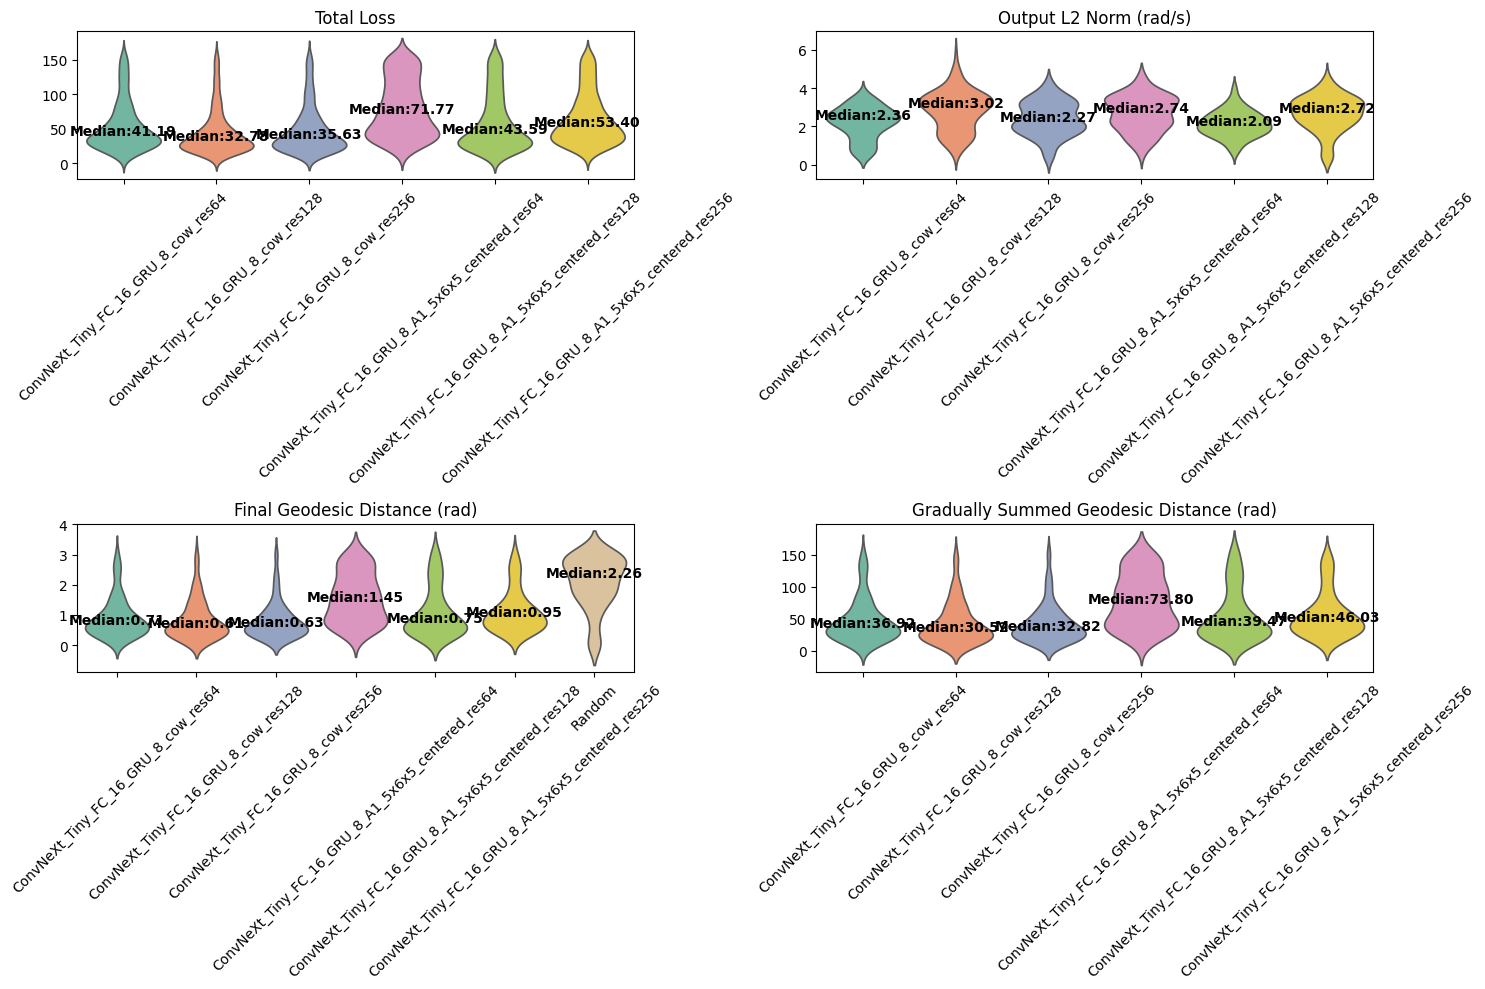

{'Total Loss': {'ConvNeXt_Tiny_FC_16_GRU_8_cow_res64': array([ 28.238562,  66.51645 ,  32.955467, ...,  83.71891 ,  41.3387  ,
         123.15534 ], dtype=float32),
  'ConvNeXt_Tiny_FC_16_GRU_8_cow_res128': array([20.316551, 36.58548 , 23.422007, ..., 97.57756 , 60.649517,
         98.363976], dtype=float32),
  'ConvNeXt_Tiny_FC_16_GRU_8_cow_res256': array([ 25.55724 ,  26.00479 ,  27.987888, ..., 146.39558 ,  59.906216,
          31.90633 ], dtype=float32),
  'ConvNeXt_Tiny_FC_16_GRU_8_A1_5x6x5_centered_res64': array([ 64.620285,  51.023064,  32.411037, ..., 155.54639 ,  84.32628 ,
         149.41364 ], dtype=float32),
  'ConvNeXt_Tiny_FC_16_GRU_8_A1_5x6x5_centered_res128': array([118.15586 ,  64.30875 ,  80.959946, ...,  43.66321 , 113.98764 ,
          17.200413], dtype=float32),
  'ConvNeXt_Tiny_FC_16_GRU_8_A1_5x6x5_centered_res256': array([110.92732 ,  49.140976,  56.42793 , ...,  54.16063 ,  33.76892 ,
          46.98261 ], dtype=float32)},
 'Output L2 Norm (rad/s)': {'ConvNeXt_T

In [39]:
configs = [
    CONFIG_PATH + "\\ConvNeXt_Tiny_FC_16_GRU_8_cow_1.1_res64_configs",
    CONFIG_PATH + "\\ConvNeXt_Tiny_FC_16_GRU_8_cow_1.1_res128_configs",
    CONFIG_PATH + '\\ConvNeXt_Tiny_FC_16_GRU_8_cow_1.1_res256_configs', 
    CONFIG_PATH + "\\ConvNeXt_Tiny_FC_16_GRU_8_A1_5x6x5_centered_1.1_res64_configs",
    CONFIG_PATH + "\\ConvNeXt_Tiny_FC_16_GRU_8_A1_5x6x5_centered_1.1_res128_configs",
    CONFIG_PATH + '\\ConvNeXt_Tiny_FC_16_GRU_8_A1_5x6x5_centered_1.1_res256_configs',
]
network_analysis_plots_CNN(configs, stage = "CNN")

Using a scheduler
Average geodesic distance: 25.454246520996094
Using a scheduler
Average geodesic distance: 15.788235664367676
Using a scheduler
Average geodesic distance: 22.586288452148438
Using a scheduler
Average geodesic distance: 60.29174041748047
Using a scheduler
Average geodesic distance: 116.70297241210938
Using a scheduler
Average geodesic distance: 108.65364074707031


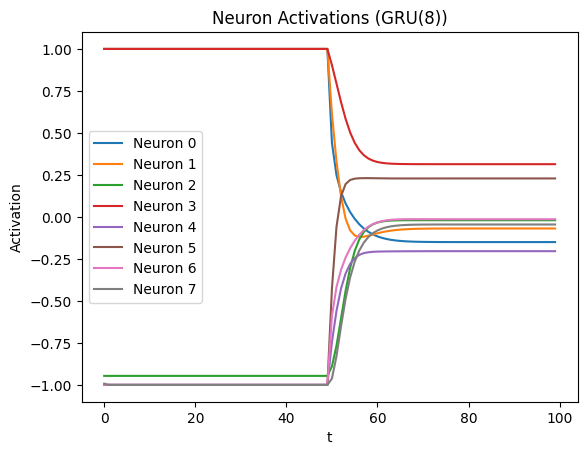

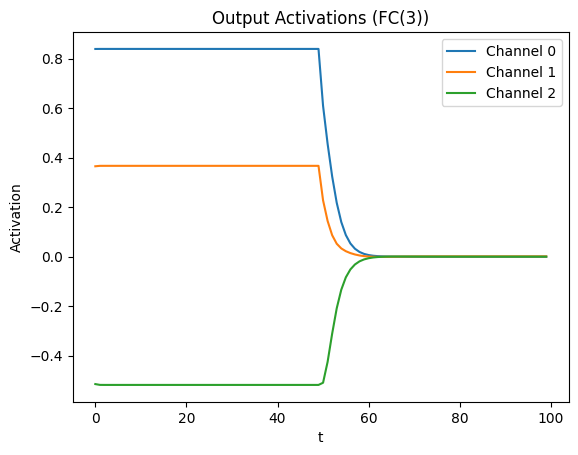

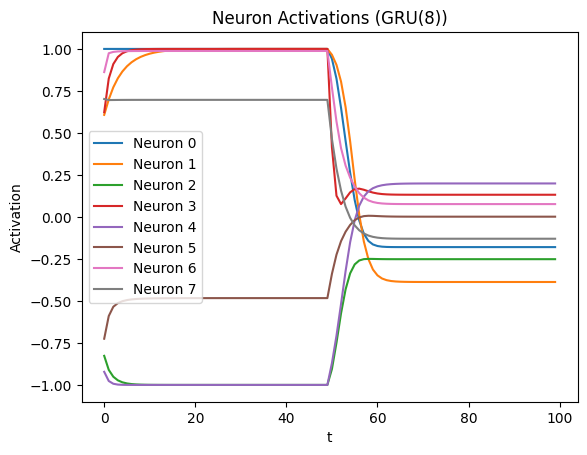

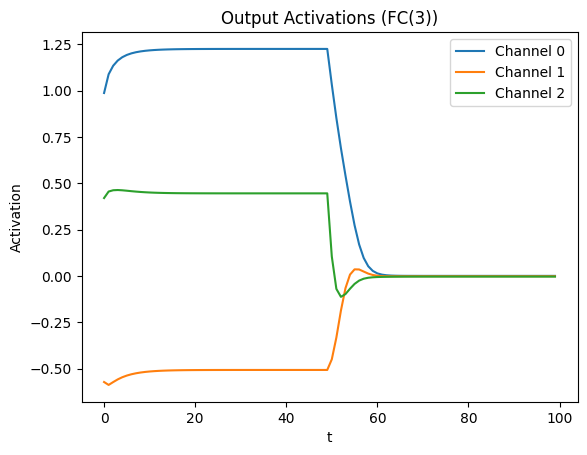

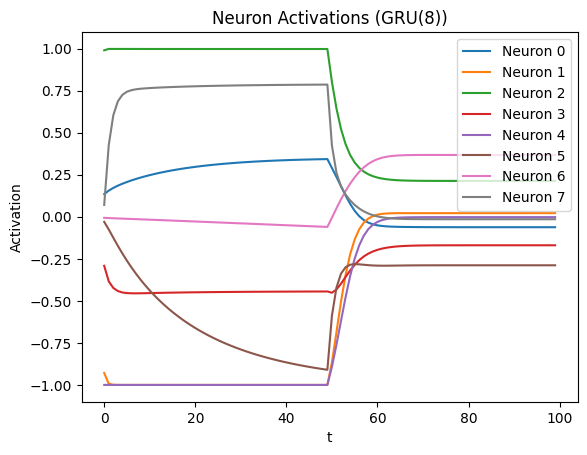

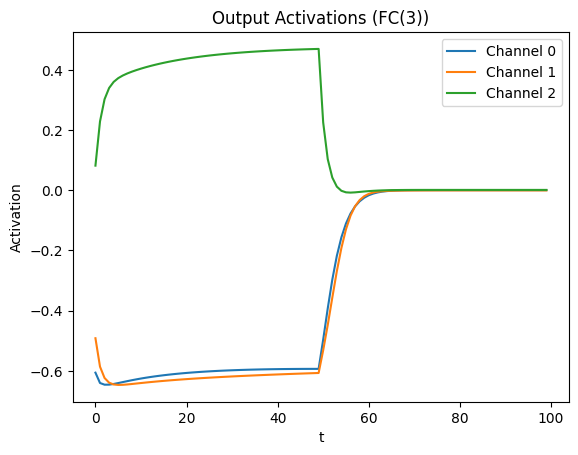

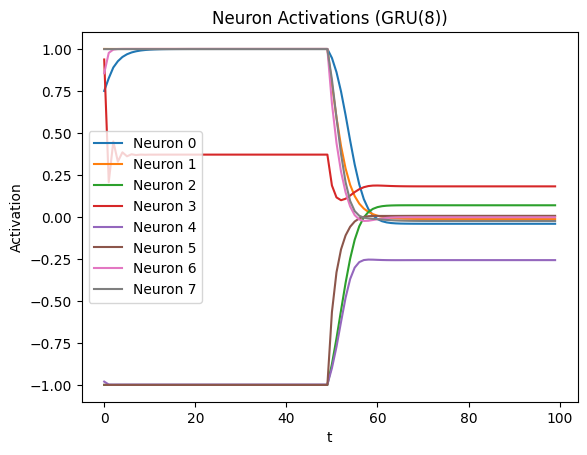

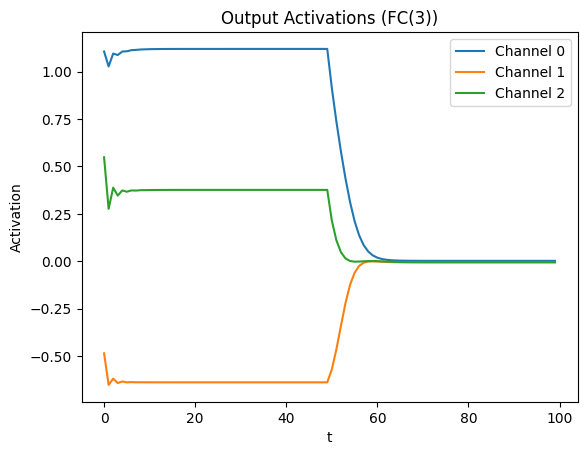

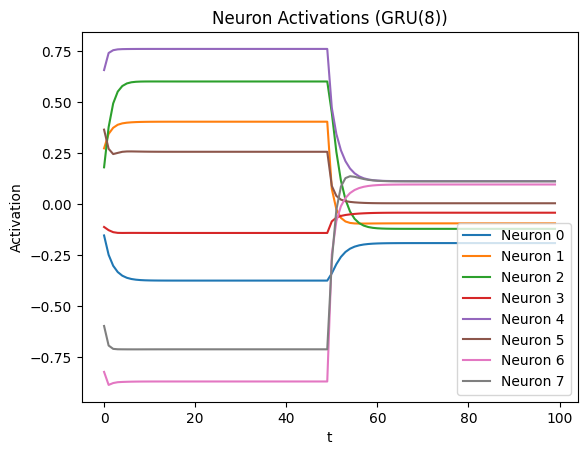

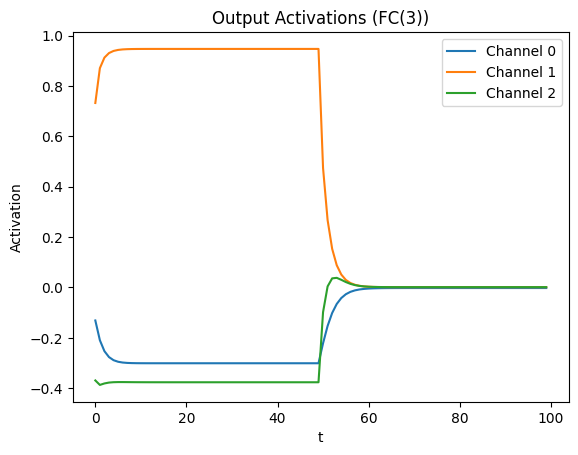

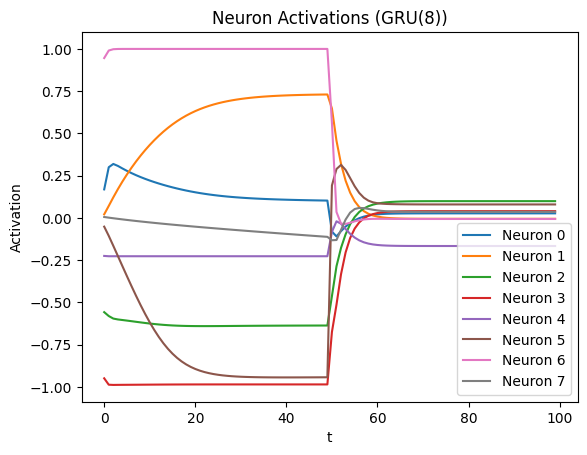

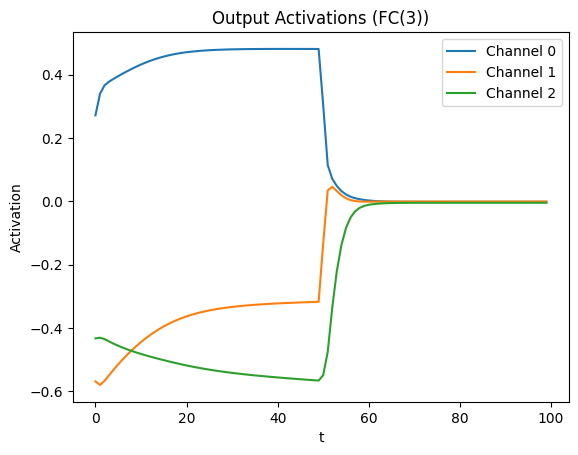

In [46]:
import matplotlib.pyplot as plt
from utils.path_settings import *

for config_path in configs: 
    config = json.load(open(config_path + ".json", "r"))
    rnn_trainer = t.Trainer(config)
    rnn_trainer.load_model(config["save_path"] + "\\best_model.pth", full=True)
    rnn_trainer.model.eval()
    # Let's print an average of geodesic distances between network output and target, for a batch of 1000 random quaternions 
    # where all parts are positive. 
    test_data = torch.load(config['training_config']['data_save_path'][:-4] + "_test.pth")
    test_dataloader = torch.utils.data.DataLoader(test_data, batch_size = 1, shuffle = False)
    features, target = next(iter(test_dataloader)) # Get a single batch
    features = features.to(config['device'])
    target = target.to(config['device'])
    rnn_trainer.model(features)
    pred = rnn_trainer.model.pred
    g_loss = rnn_trainer.distance_loss(pred, target)
    print(f"Average geodesic distance: {g_loss[0].mean()}")
    model = rnn_trainer.model


    def get_hidden_state(module, input, output):
        global hidden_states
        hidden_states.append(output[0].detach().clone())


    model.rnn.register_forward_hook(get_hidden_state)
    hidden_states = []
    out = model(features)
    activations = hidden_states[0][0:, :]  # Get the single tensor from the list
    activations = activations.view(-1, activations.shape[-1])  # Flatten to (batch_size * seq_len, hidden_unit_num)
    activations = activations.cpu().detach().numpy()

    time = np.arange(100)
    fig, ax = plt.subplots()
    for neuron in range(model.rnn.hidden_size):
        ax.plot(time, activations[:, neuron], label=f"Neuron {neuron}")
    ax.legend()
    ax.set_xlabel('t')
    ax.set_ylabel('Activation')
    ax.set_title('Neuron Activations (GRU(8))')
    save_name = config_path[(len(CONFIG_PATH)+1):-7]
    fig.savefig(FIG_PATH + "\\neuron_activations\\" + save_name + "hidden_activations.png")
    fig, ax = plt.subplots()
    time = np.arange(100)
    for output in range(3):
        ax.plot(time, out[0, :, output].cpu().detach().numpy(), label=f"Channel {output}")
    ax.legend()
    ax.set_xlabel('t')
    ax.set_ylabel('Activation')
    ax.set_title('Output Activations (FC(3))')
    fig.savefig(FIG_PATH + "\\neuron_activations\\" + save_name + "output_activations.png")